In [17]:
from typing import TypedDict,Literal
from langgraph.graph import StateGraph , START,END


In [18]:
class QuadraticState(TypedDict):
    a : int 
    b: int 
    c: int 
    
    equation : str
    discriminant : float
    result : str

In [29]:
def show_equation(state: QuadraticState) -> QuadraticState:
    a = state['a']
    b = state['b']
    c = state['c']

    result = f'{a}x² {b:+}x {c:+}'

    return {"equation": result}

In [30]:
def calculate_discriminant(state : QuadraticState)->QuadraticState:
    dsc = state['b']**2 - (4*state['a']*state['c'])
    
    return {"discriminant": dsc}

In [36]:
def real_root(state: QuadraticState):
    root1 = (-state['b'] + state['discriminant']**0.5)/(2*state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5)/(2*state['a'])
    
    result = f"the roots are {root1} and {root2}"
    
    return {"result": result}

def same_root(state: QuadraticState):
    root1 = (-state['b'] + state['discriminant']**0.5)/(2*state['a'])
    
    result = f"the roots are same {root1} "
    
    return {"result": result}


def no_real_root(state: QuadraticState):
    result = f"the roots are imaginary"
    
    return {"result": result}

In [37]:
def check_condition(state: QuadraticState)->Literal['Real root','Same root','No Real root']:
    if state['discriminant']>0:
        return "Real root"
    elif state['discriminant']==0:
        return 'Same root'
    else :
        return 'No Real root'

In [41]:
graph = StateGraph(QuadraticState)

graph.add_node('show equation',show_equation)
graph.add_node('calculate discriminant', calculate_discriminant)
graph.add_node("Real root",real_root)
graph.add_node("Same root",same_root)
graph.add_node("No Real root",no_real_root)

graph.add_edge(START,'show equation')
graph.add_edge('show equation','calculate discriminant')
graph.add_conditional_edges('calculate discriminant',check_condition)

graph.add_edge('Real root',END)
graph.add_edge('Same root',END)
graph.add_edge('No Real root',END)

In [42]:
workflow = graph.compile()

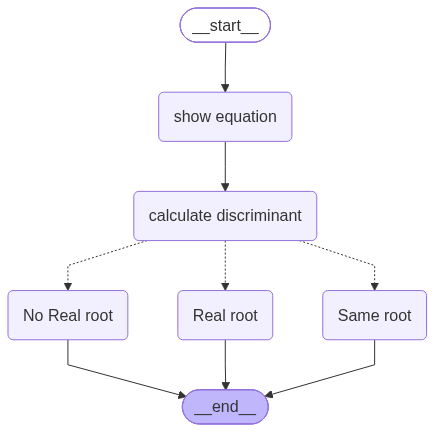

In [43]:
workflow

In [44]:
initial_state = {
    'a': 4,
    'b' : 6,
    'c' : 7
}


final_state = workflow.invoke(initial_state)

In [45]:
final_state

{'a': 4,
 'b': 6,
 'c': 7,
 'equation': '4x² +6x +7',
 'discriminant': -76,
 'result': 'the roots are imaginary'}